# Предсказване на бъдещата кариера на NBA играч (Rookie → ?)
## От първите два сезона към бъдещето

Целта на този анализ е да **предскажем какво бъдеще очаква един млад играч**, използвайки
**само данните от първите му два сезона** (rookie + sophomore).

### Целева променлива (3 класа) — определена от сезон 3 нататък
* **Out of League (отпада)** — играчът **не достига до 3-ти сезон** в лигата.
* **Role Player (ролеви играч)** — играе 3+ сезона, но със средно **под 12 точки** на мач (сезони 3+).
* **Star / Starter (звезда/титуляр)** — играе 3+ сезона със средно **над 12 точки** на мач (сезони 3+).

### Два ключови методологични принципа
1. **Разделяне във времето (без изтичане на данни).** Признаците идват **само от сезони 1–2**,
   а целевата променлива се изчислява **само от сезони 3+**. Двете множества не се припокриват,
   затова моделът наистина *прогнозира бъдещето*, а не преизчислява нещо, което вече знае.
2. **Без survivorship bias.** Включваме само играчи, дебютирали до сезон **2017-18**, така че към
   края на данните (2022-23) има поне ~5 години, в които бъдещето им вече се е случило и е
   *наблюдаемо*. Иначе млад играч с 2 сезона би бил неправилно етикетиран като „отпаднал".

### Източник на данните

Използва се датасетът [justinas/nba-players-data](https://www.kaggle.com/datasets/justinas/nba-players-data) от Kaggle. Поставете `all_seasons.csv` в папка `data/`.

```python
# pip install kagglehub
import kagglehub, shutil, os
os.makedirs('data', exist_ok=True)
p = kagglehub.dataset_download('justinas/nba-players-data')
shutil.copy(os.path.join(p, 'all_seasons.csv'), 'data/all_seasons.csv')
```

*Забележка:* всички резултати и графики по-долу вече са изчислени и запазени в notebook-а.

### 1. Импортиране на библиотеки

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, GridSearchCV)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42

/Users/user/programming/fmi/classification_cluster_analiz/izpitProject/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 2. Зареждане и подготовка на данните

In [2]:
df = pd.read_csv('data/all_seasons.csv', index_col=0)
df = df.sort_values(['player_name', 'season'])

# Номерираме сезоните на всеки играч: 1 = rookie, 2 = sophomore, ...
df['season_num'] = df.groupby('player_name').cumcount() + 1

print(f'Общо редове (играч × сезон): {len(df)}')
print(f'Уникални играчи            : {df["player_name"].nunique()}')

Общо редове (играч × сезон): 12844
Уникални играчи            : 2551


### 3. Подбор на играчи с „наблюдаемо бъдеще" (без survivorship bias)

Запазваме само играчи, които:
- са **дебютирали до сезон 2017-18** (имаме поне ~5 години, за да видим бъдещето им);
- имат **поне 2 изиграни сезона** (нужни ни за признаците).

In [3]:
debut    = df[df['season_num'] == 1].set_index('player_name')['season']
nseasons = df.groupby('player_name')['season_num'].max()

eligible = debut[debut <= '2017-18'].index.intersection(nseasons[nseasons >= 2].index)
d = df[df['player_name'].isin(eligible)]

print(f'Играчи с дебют <= 2017-18 и >= 2 сезона: {len(eligible)}')

Играчи с дебют <= 2017-18 и >= 2 сезона: 1634


### 4. Целева променлива — изчислена от сезон 3 нататък

За всеки играч гледаме **само сезони 3+**: дали изобщо е играл там и каква е средната му
резултатност. Това е „бъдещето", което моделът ще се опита да предскаже.

In [4]:
# Статистика от "бъдещето" (сезони 3+)
future = d[d['season_num'] >= 3].groupby('player_name').agg(
    fut_pts=('pts', 'mean')).reindex(eligible)
played_3plus = d[d['season_num'] >= 3].groupby('player_name').size().reindex(eligible).fillna(0)
future['fut_pts'] = future['fut_pts'].fillna(0)

def future_class(name):
    if played_3plus[name] == 0:
        return 'Out of League'          # не достига 3-ти сезон
    elif future.loc[name, 'fut_pts'] >= 12:
        return 'Star/Starter'           # резултатен в бъдеще
    else:
        return 'Role Player'            # закрепва се, но в ограничена роля

target = pd.Series({n: future_class(n) for n in eligible}, name='career_class')
print('Разпределение на класовете (бъдеще):')
print(target.value_counts())

Разпределение на класовете (бъдеще):
career_class
Role Player      1137
Out of League     264
Star/Starter      233
Name: count, dtype: int64


### 5. Признаци — само от сезони 1 и 2

Сливаме rookie (yr1) и sophomore (yr2) сезон. Освен суровите статистики добавяме:
- **„Sophomore leap" признаци** — разликата между 2-ри и 1-ви сезон (`*_growth`), която улавя
  тенденцията на развитие;
- **`draft_num`** — номер в драфта (силен предиктор; недрафтираните получават условно 61);
- **`gp` (изиграни мачове)** — индикатор за доверие на треньора и здраве.

In [5]:
r1 = d[d['season_num'] == 1].set_index('player_name')
r2 = d[d['season_num'] == 2].set_index('player_name')
feat = r1.join(r2, lsuffix='_yr1', rsuffix='_yr2', how='inner')

# "Sophomore leap" — растеж между двата сезона
for c in ['pts', 'reb', 'ast', 'net_rating']:
    feat[f'{c}_growth'] = feat[f'{c}_yr2'] - feat[f'{c}_yr1']

# Номер в драфта (Undrafted -> 61)
feat['draft_num'] = pd.to_numeric(feat['draft_number_yr1'], errors='coerce').fillna(61)

FEATURES = [
    'age_yr1', 'player_height_yr1', 'player_weight_yr1', 'draft_num',
    'gp_yr1', 'pts_yr1', 'reb_yr1', 'ast_yr1', 'net_rating_yr1', 'usg_pct_yr1', 'ts_pct_yr1',
    'gp_yr2', 'pts_yr2', 'reb_yr2', 'ast_yr2', 'net_rating_yr2',
    'pts_growth', 'reb_growth', 'ast_growth', 'net_rating_growth',
]

feat = feat.dropna(subset=FEATURES)
y = target.reindex(feat.index)
X = feat[FEATURES]
print(f'X: {X.shape}, y: {y.shape}, класове: {y.nunique()}')

X: (1634, 20), y: (1634,), класове: 3


**Проверка, че няма изтичане на данни.** Признакът `pts_yr2` корелира с бъдещата
резултатност, но това е **легитимна прогнозна връзка**, а не тавтология — целевата променлива
се изчислява от *други* сезони (3+), които изобщо не участват в признаците.

In [6]:
corr = feat['pts_yr2'].corr(future['fut_pts'].reindex(feat.index))
print(f'Корелация pts_yr2 (признак) с fut_pts (от сезони 3+): {corr:.3f}')
print('-> легитимна прогноза: умерена корелация, а не 1.0 (както би било при изтичане)')

Корелация pts_yr2 (признак) с fut_pts (от сезони 3+): 0.760
-> легитимна прогноза: умерена корелация, а не 1.0 (както би било при изтичане)


### 6. Разпределение на класовете

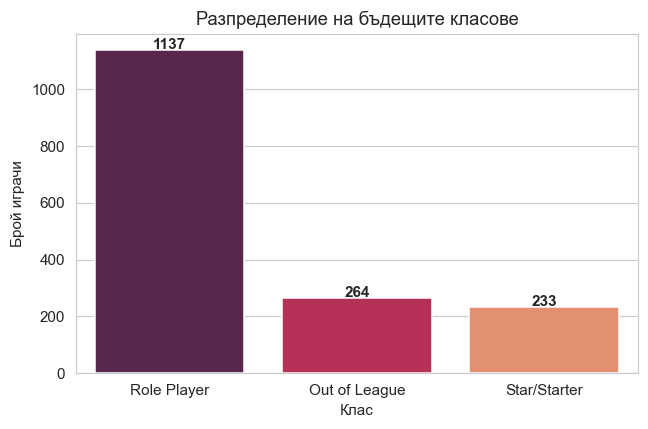

In [7]:
plt.figure(figsize=(6, 4))
order = y.value_counts().index
sns.countplot(x=y, order=order, palette='rocket')
plt.title('Разпределение на бъдещите класове')
plt.xlabel('Клас'); plt.ylabel('Брой играчи')
for i, v in enumerate(y.value_counts()[order]):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout(); plt.show()

Класовете са **небалансирани** (`Role Player` доминира). Затова:
- ще използваме `class_weight='balanced'`, за да не игнорира моделът редките класове;
- ще гледаме **macro F1** (а не само accuracy), който усреднява по класове и наказва за пренебрегване на малцинствата;
- ще сравняваме с **базова линия** = винаги да предсказваме мажоритарния клас.

### 7. Обучение, кръстосана валидация и базова линия

Използваме `RandomForestClassifier` с `class_weight='balanced'`. Освен единичен train/test split,
прилагаме **5-кратна стратифицирана кръстосана валидация** (изискване на проекта) и сравняваме с
тривиалната базова линия.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

rf = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                            random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_acc = cross_val_score(rf, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
cv_f1  = cross_val_score(rf, X, y, cv=cv, scoring='f1_macro', n_jobs=-1)
baseline = y.value_counts(normalize=True).max()

print(f'Holdout точност           : {accuracy_score(y_test, rf.predict(X_test)):.3f}')
print(f'CV точност (5-fold)       : {cv_acc.mean():.3f} +/- {cv_acc.std()*2:.3f}')
print(f'CV macro-F1 (5-fold)      : {cv_f1.mean():.3f} +/- {cv_f1.std()*2:.3f}')
print(f'Базова линия (мажоритарен): {baseline:.3f}')
print(f'Прираст над базовата линия: {(cv_acc.mean()-baseline)*100:+.1f} проц. пункта')

Holdout точност           : 0.731
CV точност (5-fold)       : 0.753 +/- 0.032
CV macro-F1 (5-fold)      : 0.592 +/- 0.051
Базова линия (мажоритарен): 0.696
Прираст над базовата линия: +5.8 проц. пункта


### 8. Оптимизация на хиперпараметри (`GridSearchCV`)

Оптимизираме по **macro-F1**, защото при небалансирани класове той е по-информативен от accuracy.

In [9]:
param_grid = {
    'n_estimators':     [200, 300],
    'max_depth':        [8, 12, None],
    'min_samples_leaf': [1, 2, 4],
}
grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    param_grid, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
print('Най-добри параметри:', grid.best_params_)
print(f'Най-добър CV macro-F1: {grid.best_score_:.3f}')
print(f'\nHoldout точност (оптимизиран): {accuracy_score(y_test, best_rf.predict(X_test)):.3f}')

Fitting 5 folds for each of 18 candidates, totalling 90 fits


Най-добри параметри: {'max_depth': 8, 'min_samples_leaf': 4, 'n_estimators': 300}
Най-добър CV macro-F1: 0.642

Holdout точност (оптимизиран): 0.737


### 9. Резултати — матрица на грешките и важност на признаците

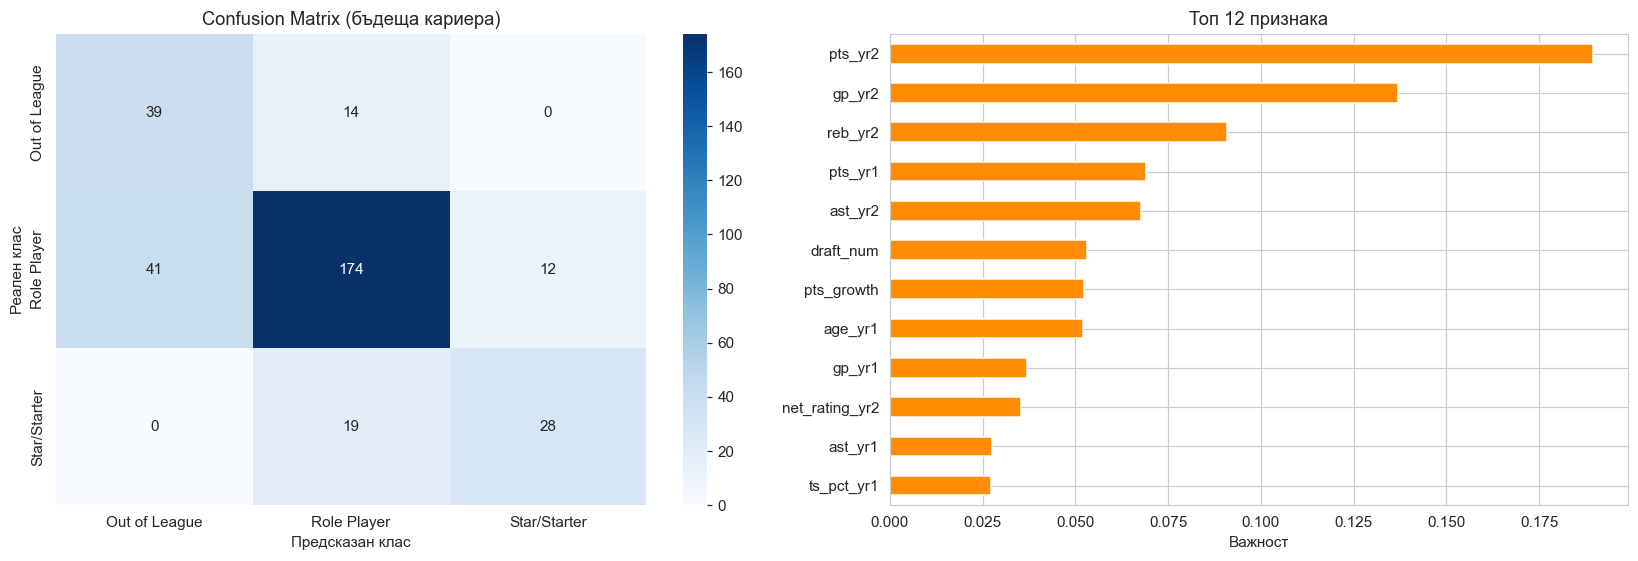

               precision    recall  f1-score   support

Out of League       0.49      0.74      0.59        53
  Role Player       0.84      0.77      0.80       227
 Star/Starter       0.70      0.60      0.64        47

     accuracy                           0.74       327
    macro avg       0.68      0.70      0.68       327
 weighted avg       0.76      0.74      0.74       327



In [10]:
y_pred = best_rf.predict(X_test)
labels = ['Out of League', 'Role Player', 'Star/Starter']

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))

cm = confusion_matrix(y_test, y_pred, labels=labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_xlabel('Предсказан клас'); axes[0].set_ylabel('Реален клас')
axes[0].set_title('Confusion Matrix (бъдеща кариера)')

imp = pd.Series(best_rf.feature_importances_, index=FEATURES).sort_values().tail(12)
imp.plot.barh(ax=axes[1], color='darkorange')
axes[1].set_xlabel('Важност'); axes[1].set_title('Топ 12 признака')

plt.tight_layout(); plt.show()

print(classification_report(y_test, y_pred, labels=labels))

Благодарение на `class_weight='balanced'` моделът **не пренебрегва редките класове**: улавя
значителна част от бъдещите „отпаднали" (Out of League) и „звезди" (Star/Starter), а не просто
предсказва доминиращия Role Player. Най-силни предиктори са **резултатността и изиграните мачове
във втория сезон** и **номерът в драфта** — логично, защото те отразяват както таланта, така и
доверието на организацията към играча.

### 10. Обяснителен ИИ (SHAP) — защо моделът предсказва „звезда"?

Чрез SHAP разглеждаме кои признаци тласкат прогнозата към класа **Star/Starter**.

SHAP — глобална важност за класа 'Star/Starter':


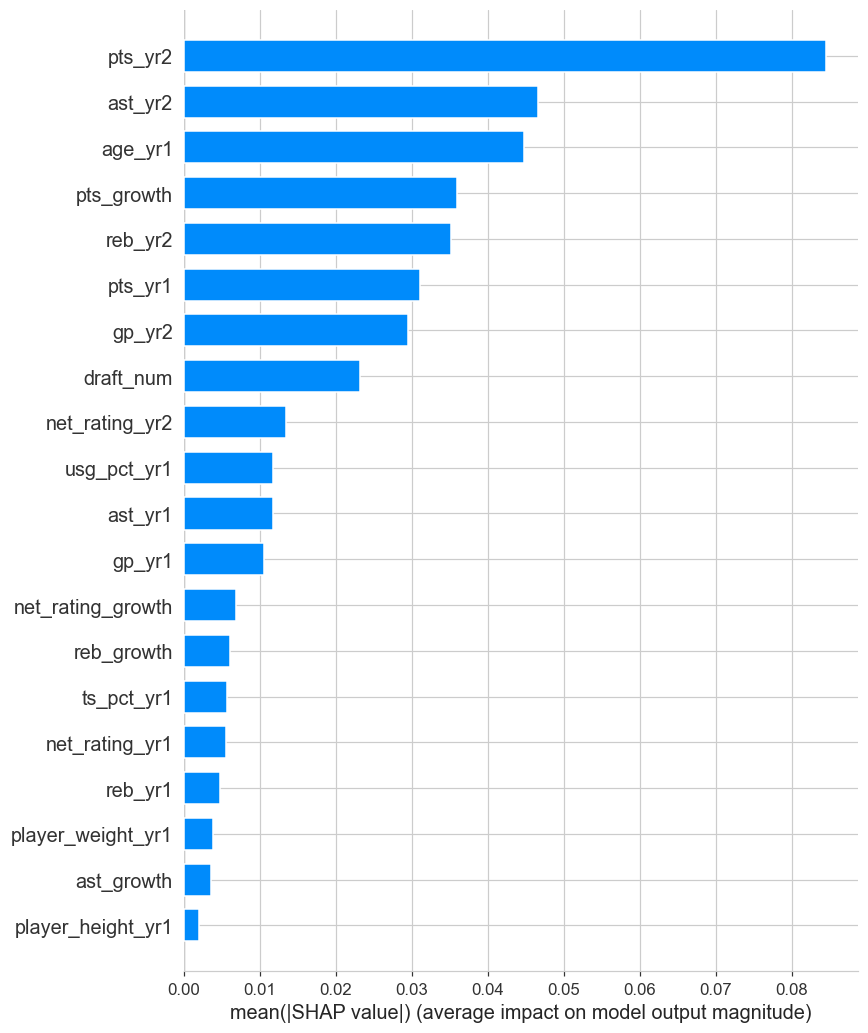

In [11]:
shap.initjs()
explainer = shap.TreeExplainer(best_rf)

X_sample = X_test.head(150)
shap_obj = explainer(X_sample)

star_idx = list(best_rf.classes_).index('Star/Starter')
print("SHAP — глобална важност за класа 'Star/Starter':")
shap.summary_plot(shap_obj[:, :, star_idx], X_sample, plot_type='bar', show=True)

**Изводи от SHAP.** Тъй като целевата променлива се изчислява от сезони 3+, които **не участват**
в признаците, изводите вече **не са тавтологични**. Виждаме, че бъдещата звездност се определя
най-силно от резултатността и обема игра във втория сезон, от растежа спрямо първия сезон
(„sophomore leap") и от позицията в драфта — т.е. ранните сигнали наистина носят прогнозна
информация за бъдещето.

## Сравнение с други анализи в Kaggle

Прогнозирането на кариерата на NBA новобранци е популярна задача. Най-известният еталон е
**„5-Year NBA Rookie Classification"** — предсказване дали играч ще изкара **поне 5 сезона** в
лигата. Сравнението с тези анализи показва къде нашият подход се различава.

| Анализ | Цел (target) | Признаци | Модел / точност | Разлика спрямо нашия проект |
|---|---|---|---|---|
| **5-Year Rookie Classification** (Kaggle / mexwell) | **Бинарна**: ≥5 сезона да/не | само **rookie** сезон | LogReg ~0.72; RF ~0.75 | Ние имаме **3 класа** (отпада/ролеви/звезда), не само оцеляване |
| *NBA Rookie Longevity Project* (mamadoudiallo) | Бинарна дълготрайност | rookie статистики | LogReg / RF | Не адресира survivorship bias; ние филтрираме по дебют |
| *Predictive Modeling of NBA Player Performance* (xreina8) | Регресия на бъдеща продуктивност | сезонни статистики | различни регресори | Ние решаваме класификация с интерпретируеми класове |
| *Predicting NBA Hall of Famers* (Medium / Mamidyala) | Бинарна: HoF да/не | rookie сезон | класификация | Друг, много по-рядък клас (екстремен дисбаланс) |

**Основни разлики на нашия подход:**
1. **3 класа вместо бинарна оцеляване-задача.** Стандартният Kaggle еталон предсказва само „ще
   изкара ли 5 години". Ние разделяме бъдещето на **отпада / ролеви / звезда** — по-информативно,
   защото различава *оцеляване* от *качество* на кариерата.
2. **Два сезона + „sophomore leap".** Повечето анализи ползват **само rookie** сезона. Ние добавяме
   втория сезон и **признаци за растеж** (`*_growth`), които улавят траекторията на развитие.
3. **Изрично третиране на survivorship bias.** Прегледаните notebook-и обикновено не го адресират —
   ние включваме само играчи с вече „случило се" бъдеще (дебют ≤ 2017-18).
4. **Съпоставими резултати.** Нашата CV точност **~0.75** е на нивото на тунинговано Random Forest
   при бинарния еталон (~0.75) — а решаваме **по-трудна 3-класова** задача. Затова сравняваме и
   **прираста над базовата линия** и **macro-F1**, а не само суровата точност (различният брой
   класове прави самата accuracy несравнима директно).

*Източници:* [5-Year NBA Rookie Classification](https://www.kaggle.com/datasets/mexwell/5-year-nba-rookie-classification) ·
[NBA Rookie Longevity Project](https://www.kaggle.com/code/mamadoudiallo/nba-rookie-longevity-project) ·
[Predictive Modeling of NBA Player Performance](https://www.kaggle.com/code/xreina8/predictive-modeling-of-nba-player-performance) ·
[Logistic Regression — 5-Year Rookie (Medium)](https://medium.com/@ammasanaswar/logistic-regression-analysis-5-year-nba-rookie-classification-ab6d43c2a1e4)

## Изводи

1. **Поставихме коректна прогнозна задача:** признаци от сезони 1–2 → бъдеще от сезони 3+. Така
   няма изтичане на данни и резултатите отразяват реална прогнозна способност.
2. **Премахнахме survivorship bias**, като включихме само играчи с вече „случило се" бъдеще
   (дебют до 2017-18).
3. Моделът постига **CV точност ~0.75** при **базова линия ~0.70**, а по-важното — благодарение на
   `class_weight='balanced'` и оптимизация по **macro-F1** разпознава и трите класа, включително
   редките „звезди" и „отпаднали".
4. **Най-силни предиктори** за бъдещето: резултатност и изиграни мачове във втория сезон, растежът
   между двата сезона и номерът в драфта.
5. Задачата е по-трудна от класификацията на позиция (по-малко сигнал в данните, по-голяма
   случайност в кариерите) — което е очаквано: бъдещето на един спортист зависи и от множество
   фактори извън ранната статистика (контузии, смяна на отбор, развитие).